# Reto 3 – Clasificación de biomasa

**Objetivo:** Clasificar los ecosistemas según su biomasa y variables ambientales asociadas.

Carga el conjunto de datos y explora las variables relevantes.

In [1]:
import pandas as pd

df = pd.read_csv("../data/resultados_experimentos.csv")
df.head()

,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


## Exploración inicial
Describe las columnas y analiza los tipos de datos.

In [4]:
# Revisar las columnas del DataFrame
print("Columnas del DataFrame:")
print(df.columns)

print("\nInformación general:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

Columnas del DataFrame:
Index(['sitio', 'temperatura', 'humedad', 'luz', 'biomasa'], dtype='object')

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sitio        20 non-null     object 
 1   temperatura  20 non-null     float64
 2   humedad      20 non-null     float64
 3   luz          20 non-null     int64  
 4   biomasa      20 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 932.0+ bytes

Estadísticas descriptivas:


,temperatura,humedad,luz,biomasa
count,20.000000,20.000000,20.000000,20.000000
mean,20.695000,78.090000,901.000000,196.415000
std,3.259234,8.047615,307.177816,84.389369
min,14.800000,63.200000,395.000000,54.800000
25%,18.600000,72.350000,670.250000,105.650000
50%,20.400000,76.250000,893.500000,227.050000
75%,23.650000,82.975000,1048.000000,253.975000
max,27.700000,93.000000,1482.000000,315.600000


In [5]:
# Limpiar nombres de columnas
df.columns = df.columns.str.strip().str.lower()

df.head()

,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


## Desarrollo del reto
Aplica funciones y análisis según el objetivo. Usa `def` para definir tus funciones.

In [6]:
def clasificar_biomasa(b):
    """
    Clasifica la biomasa según los criterios del reto:
    - alta: biomasa mayor a 250
    - media: biomasa entre 150 y 250
    - baja: biomasa menor a 150
    """
    if b > 250:
        return "alta"
    elif b >= 150:
        return "media"
    else:
        return "baja"

In [7]:
df["nivel_biomasa"] = df["biomasa"].apply(clasificar_biomasa)

df.head()

,sitio,temperatura,humedad,luz,biomasa,nivel_biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8,alta
1,Humedal Facatativá,18.0,89.7,395,225.8,media
2,Río San Francisco,17.2,85.4,647,237.5,media
3,Ladera de La Vega,21.7,81.4,769,252.4,alta
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7,alta


In [8]:
tabla_biomasa = df.groupby("nivel_biomasa").size().reset_index(name="numero_sitios")

tabla_biomasa

,nivel_biomasa,numero_sitios
0,alta,7
1,baja,7
2,media,6


In [9]:
promedios_biomasa = df.groupby("nivel_biomasa")[["temperatura", "humedad", "luz"]].mean()

promedios_biomasa

,temperatura,humedad,luz
nivel_biomasa,,,
alta,22.528571,78.814286,1012.571429
baja,20.071429,76.000000,924.142857
media,19.283333,79.683333,743.833333


In [10]:
orden = ["baja", "media", "alta"]

promedios_biomasa = promedios_biomasa.reindex(orden)

promedios_biomasa

,temperatura,humedad,luz
nivel_biomasa,,,
baja,20.071429,76.000000,924.142857
media,19.283333,79.683333,743.833333
alta,22.528571,78.814286,1012.571429


Matplotlib is building the font cache; this may take a moment.


NameError: name 'plt' is not defined

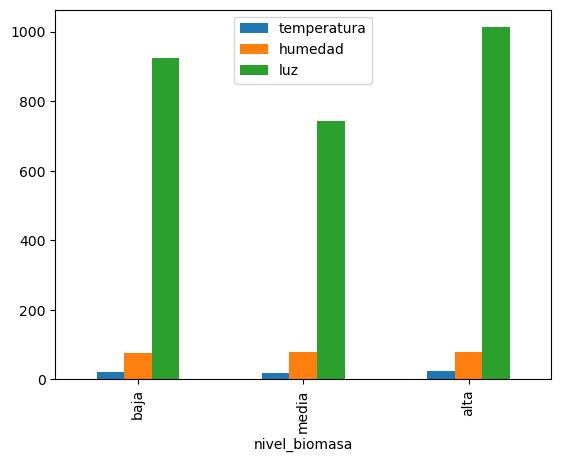

In [11]:
promedios_biomasa.plot(kind="bar")

plt.title("Promedio de variables ambientales por nivel de biomasa")
plt.xlabel("Nivel de biomasa")
plt.ylabel("Promedio")
plt.xticks(rotation=0)
plt.show()

In [12]:
df.to_csv("../data/reto3_resultado.csv", index=False)

print("Archivo reto3_resultado.csv generado correctamente.")

Archivo reto3_resultado.csv generado correctamente.


## Interpretación de resultados
Escribe tus observaciones y conclusiones sobre los patrones encontrados.

## Conclusión

En este reto se analizó la biomasa de los sitios experimentales y se clasificó en tres niveles: baja, media y alta.

Primero se cargó el conjunto de datos y se exploraron las variables principales. Luego se creó la función `clasificar_biomasa(b)`, la cual permite asignar una categoría a cada sitio según el valor de biomasa registrado.

Después se aplicó la función al DataFrame para crear la columna `nivel_biomasa`. Con esta clasificación se generó una tabla resumen con el número de sitios por nivel de biomasa.

Finalmente, se calcularon los promedios de temperatura, humedad y luz para cada nivel de biomasa usando `groupby`, y se creó un gráfico de barras para comparar las variables ambientales según la productividad de los sitios.